In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from rapidfuzz import process, fuzz
import numpy as np

In [2]:
df_matches = pd.read_csv("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/clean/merged_matches.csv")

In [4]:
cols = ["p1_first_serve", "p1_1st_serve_points_won", "p1_2nd_serve_points_won",                             # Defining columns for stats
        "p1_1st_serve_return_points_won", "p1_service_points_won", "p1_2nd_serve_return_points_won", "p1_return_points_won", "p1_total_points_won",
        "p2_first_serve", "p2_1st_serve_points_won", "p2_2nd_serve_points_won",
        "p2_1st_serve_return_points_won", "p2_service_points_won", "p2_2nd_serve_return_points_won", "p2_return_points_won", "p2_total_points_won"]
cols2 = ["p1_break_points_saved", "p1_break_points_converted", "p1_net_points_won",
        "p2_break_points_saved", "p2_break_points_converted", "p2_net_points_won"]
new_cols = ["p2_break_point_opportunities", "p1_break_point_opportunities", "p1_net_points_played",
        "p2_net_points_played"]
tot_cols = cols+cols2+new_cols + ["p2_serve_rating", "p2_aces",
                                  "p2_double_faults", "p2_service_games_played",
                                  "p2_return_rating", "p2_return_games_played",
                                  "p2_winners", "p2_unforced_errors", "p2_max_speed",
                                  "p2_1st_serve_average_speed", "p2_2nd_serve_average_speed",
                                  "p1_break_point_opportunities", "p1_net_points_played",
                                  'p1_serve_rating', 'p1_aces', 'p1_double_faults',
       'p1_first_serve', 'p1_1st_serve_points_won', 'p1_2nd_serve_points_won',
       'p1_break_points_saved', 'p1_service_games_played', 'p1_return_rating',
       'p1_1st_serve_return_points_won', 'p1_2nd_serve_return_points_won',
       'p1_break_points_converted', 'p1_return_games_played',
       'p1_net_points_won', 'p1_winners', 'p1_unforced_errors',
       'p1_service_points_won', 'p1_return_points_won', 'p1_total_points_won',
       'p1_max_speed', 'p1_1st_serve_average_speed',
       'p1_2nd_serve_average_speed', 'p1_break_point_opportunities',
       'p1_net_points_played']
tot_cols = list(set(tot_cols))

In [5]:
for col in tot_cols:
    if 'p2' in col:
        print(col)

p2_1st_serve_average_speed
p2_net_points_played
p2_1st_serve_points_won
p2_2nd_serve_return_points_won
p2_max_speed
p2_net_points_won
p2_double_faults
p2_first_serve
p2_1st_serve_return_points_won
p2_total_points_won
p2_service_points_won
p2_winners
p2_serve_rating
p2_2nd_serve_average_speed
p2_2nd_serve_points_won
p2_break_points_converted
p2_break_points_saved
p2_unforced_errors
p2_return_rating
p2_break_point_opportunities
p2_service_games_played
p2_aces
p2_return_games_played
p2_return_points_won


In [6]:
p1_df = df_matches.copy()

for col in tot_cols:
    if 'p2' in col:
        p1_df.drop(columns=col, inplace=True)

p1_df

,match_date,player_1,player_2,duration,match_round,player_1_scores,player_2_scores,winner,result,match_id,...,p1_unforced_errors,p1_service_points_won,p1_return_points_won,p1_total_points_won,p1_max_speed,p1_1st_serve_average_speed,p1_2nd_serve_average_speed,p1_break_point_opportunities,p1_net_points_played,Unnamed: 0
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,ms001,...,6.0,0.44,0.20,0.29,NaN,NaN,NaN,0.0,0.0,NaN
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,ms003,...,22.0,0.75,0.27,0.51,NaN,NaN,NaN,2.0,5.0,NaN
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,ms002,...,16.0,0.80,0.32,0.55,NaN,NaN,NaN,2.0,17.0,NaN
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,ms004,...,15.0,0.68,0.20,0.46,NaN,NaN,NaN,1.0,4.0,NaN
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,ms007,...,14.0,0.50,0.23,0.35,NaN,NaN,NaN,0.0,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4094,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,37.0,0.69,0.37,0.52,NaN,NaN,NaN,8.0,8.0,34.0
4095,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,44.0,0.58,0.35,0.48,NaN,NaN,NaN,13.0,5.0,35.0
4096,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,21.0,0.68,0.47,0.57,NaN,NaN,NaN,4.0,13.0,36.0
4097,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,24.0,0.67,0.34,0.48,NaN,NaN,NaN,5.0,3.0,37.0


In [7]:
p2_df = df_matches.copy()

for col in tot_cols:
    if 'p1' in col:
        p2_df.drop(columns=col, inplace=True)

p2_df

,match_date,player_1,player_2,duration,match_round,player_1_scores,player_2_scores,winner,result,match_id,...,p2_unforced_errors,p2_service_points_won,p2_return_points_won,p2_total_points_won,p2_max_speed,p2_1st_serve_average_speed,p2_2nd_serve_average_speed,p2_break_point_opportunities,p2_net_points_played,Unnamed: 0
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,ms001,...,4.0,0.80,0.56,0.71,NaN,NaN,NaN,1.0,2.0,NaN
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,ms003,...,21.0,0.73,0.25,0.49,NaN,NaN,NaN,0.0,3.0,NaN
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,ms002,...,21.0,0.68,0.20,0.45,NaN,NaN,NaN,4.0,17.0,NaN
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,ms004,...,30.0,0.80,0.32,0.54,NaN,NaN,NaN,5.0,7.0,NaN
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,ms007,...,10.0,0.77,0.50,0.65,NaN,NaN,NaN,4.0,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4094,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,49.0,0.63,0.31,0.48,NaN,NaN,NaN,9.0,27.0,34.0
4095,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,45.0,0.65,0.42,0.52,NaN,NaN,NaN,10.0,6.0,35.0
4096,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,28.0,0.53,0.32,0.43,NaN,NaN,NaN,3.0,2.0,36.0
4097,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,25.0,0.66,0.33,0.52,NaN,NaN,NaN,3.0,9.0,37.0


In [8]:
p1_df.rename(columns={"player_1": "player", "player_2": "opponent", "player_1_scores": "player_scores",
                      "player_2_scores": "opponent_scores", "p1_id": "id", "p2_id": "opponent_id", "p1_set1": "set1",
                      'p1_set2': 'set2',
                    'p1_set3': 'set3',
                    'p1_set4': 'set4',
                    'p1_set5': 'set5',
                    'p2_set1': 'opponent_set1',
                    'p2_set2': 'opponent_set2',
                    'p2_set3': 'opponent_set3',
                    'p2_set4': 'opponent_set4',
                    'p2_set5': 'opponent_set5',
                    'p1_serve_rating': 'serve_rating',
                    'p1_aces': 'aces',
                    'p1_double_faults': 'double_faults',
                    'p1_first_serve': 'first_serve',
                    'p1_1st_serve_points_won': '1st_serve_points_won',
                    'p1_2nd_serve_points_won': '2nd_serve_points_won',
                    'p1_break_points_saved': 'break_points_saved',
                    'p1_service_games_played': 'service_games_played',
                    'p1_return_rating': 'return_rating',
                    'p1_1st_serve_return_points_won': '1st_serve_return_points_won',
                    'p1_2nd_serve_return_points_won': '2nd_serve_return_points_won',
                    'p1_break_points_converted': 'break_points_converted',
                    'p1_return_games_played': 'return_games_played',
                    'p1_net_points_won': 'net_points_won',
                    'p1_winners': 'winners',
                    'p1_unforced_errors': 'unforced_errors',
                    'p1_service_points_won': 'service_points_won',
                    'p1_return_points_won': 'return_points_won',
                    'p1_total_points_won': 'total_points_won',
                    'p1_max_speed': 'max_speed',
                    'p1_1st_serve_average_speed': '1st_serve_average_speed',
                    'p1_2nd_serve_average_speed': '2nd_serve_average_speed',
                    'p1_break_point_opportunities': 'break_point_opportunities',
                    'p1_net_points_played': 'net_points_played'}, inplace=True)

In [9]:
p2_df.rename(columns={"player_1": "opponent", "player_2": "player", "player_1_scores": "opponent_scores",
                      "player_2_scores": "player_scores", "p2_id": "id", "p1_id": "opponent_id",
                      'p1_set1': 'opponent_set1',
                        'p1_set2': 'opponent_set2',
                        'p1_set3': 'opponent_set3',
                        'p1_set4': 'opponent_set4',
                        'p1_set5': 'opponent_set5',
                        'p2_set1': 'set1',
                        'p2_set2': 'set2',
                        'p2_set3': 'set3',
                        'p2_set4': 'set4',
                        'p2_set5': 'set5',
                        'p2_serve_rating': 'serve_rating',
                        'p2_aces': 'aces',
                        'p2_double_faults': 'double_faults',
                        'p2_first_serve': 'first_serve',
                        'p2_1st_serve_points_won': '1st_serve_points_won',
                        'p2_2nd_serve_points_won': '2nd_serve_points_won',
                        'p2_break_points_saved': 'break_points_saved',
                        'p2_service_games_played': 'service_games_played',
                        'p2_return_rating': 'return_rating',
                        'p2_1st_serve_return_points_won': '1st_serve_return_points_won',
                        'p2_2nd_serve_return_points_won': '2nd_serve_return_points_won',
                        'p2_break_points_converted': 'break_points_converted',
                        'p2_return_games_played': 'return_games_played',
                        'p2_net_points_won': 'net_points_won',
                        'p2_winners': 'winners',
                        'p2_unforced_errors': 'unforced_errors',
                        'p2_service_points_won': 'service_points_won',
                        'p2_return_points_won': 'return_points_won',
                        'p2_total_points_won': 'total_points_won',
                        'p2_max_speed': 'max_speed',
                        'p2_1st_serve_average_speed': '1st_serve_average_speed',
                        'p2_2nd_serve_average_speed': '2nd_serve_average_speed',
                        'p2_break_point_opportunities': 'break_point_opportunities',
                        'p2_net_points_played': 'net_points_played'}, inplace=True)

In [10]:
p1_df.columns == p2_df.columns

array([ True, False, False,  True,  True, False, False,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [11]:
p1_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,match_id,...,unforced_errors,service_points_won,return_points_won,total_points_won,max_speed,1st_serve_average_speed,2nd_serve_average_speed,break_point_opportunities,net_points_played,Unnamed: 0
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,ms001,...,6.0,0.44,0.20,0.29,NaN,NaN,NaN,0.0,0.0,NaN
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,ms003,...,22.0,0.75,0.27,0.51,NaN,NaN,NaN,2.0,5.0,NaN
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,ms002,...,16.0,0.80,0.32,0.55,NaN,NaN,NaN,2.0,17.0,NaN
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,ms004,...,15.0,0.68,0.20,0.46,NaN,NaN,NaN,1.0,4.0,NaN
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,ms007,...,14.0,0.50,0.23,0.35,NaN,NaN,NaN,0.0,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4094,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,37.0,0.69,0.37,0.52,NaN,NaN,NaN,8.0,8.0,34.0
4095,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,44.0,0.58,0.35,0.48,NaN,NaN,NaN,13.0,5.0,35.0
4096,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,21.0,0.68,0.47,0.57,NaN,NaN,NaN,4.0,13.0,36.0
4097,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,24.0,0.67,0.34,0.48,NaN,NaN,NaN,5.0,3.0,37.0


In [12]:
p2_df

,match_date,opponent,player,duration,match_round,opponent_scores,player_scores,winner,result,match_id,...,unforced_errors,service_points_won,return_points_won,total_points_won,max_speed,1st_serve_average_speed,2nd_serve_average_speed,break_point_opportunities,net_points_played,Unnamed: 0
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,ms001,...,4.0,0.80,0.56,0.71,NaN,NaN,NaN,1.0,2.0,NaN
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,ms003,...,21.0,0.73,0.25,0.49,NaN,NaN,NaN,0.0,3.0,NaN
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,ms002,...,21.0,0.68,0.20,0.45,NaN,NaN,NaN,4.0,17.0,NaN
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,ms004,...,30.0,0.80,0.32,0.54,NaN,NaN,NaN,5.0,7.0,NaN
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,ms007,...,10.0,0.77,0.50,0.65,NaN,NaN,NaN,4.0,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4094,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,49.0,0.63,0.31,0.48,NaN,NaN,NaN,9.0,27.0,34.0
4095,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,45.0,0.65,0.42,0.52,NaN,NaN,NaN,10.0,6.0,35.0
4096,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,28.0,0.53,0.32,0.43,NaN,NaN,NaN,3.0,2.0,36.0
4097,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,25.0,0.66,0.33,0.52,NaN,NaN,NaN,3.0,9.0,37.0


In [13]:
player_stats_df = pd.concat([p1_df, p2_df], ignore_index=True)

In [14]:
player_stats_df.sort_values(by="match_date", ascending=False)

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,match_id,...,unforced_errors,service_points_won,return_points_won,total_points_won,max_speed,1st_serve_average_speed,2nd_serve_average_speed,break_point_opportunities,net_points_played,Unnamed: 0
8098,2025-07-27 00:00:00,A. De Minaur,A. Davidovich Fokina,0 days 03:03:35,Final,5 6 7,7 1 6(3),A. De Minaur,Completed,ms001,...,45.0,0.63,0.42,0.52,NaN,NaN,NaN,9.0,12.0,0.0
3999,2025-07-27 00:00:00,A. Davidovich Fokina,A. De Minaur,0 days 03:03:35,Final,7 1 6(3),5 6 7,A. De Minaur,Completed,ms001,...,57.0,0.58,0.37,0.48,NaN,NaN,NaN,8.0,7.0,0.0
8099,2025-07-26 00:00:00,B. Shelton,A. Davidovich Fokina,0 days 01:19:34,Semi-Finals,2 5,6 7,A. Davidovich Fokina,Completed,ms002,...,35.0,0.58,0.27,0.43,NaN,NaN,NaN,1.0,11.0,1.0
8061,2025-07-26 00:00:00,L. Darderi,C. Taberner,0 days 01:26:44,Final,6 6,3 3,L. Darderi,Completed,ms001,...,6.0,0.84,0.40,0.59,NaN,NaN,NaN,5.0,4.0,0.0
8159,2025-07-26 00:00:00,A. Cazaux,A. Bublik,0 days 01:24:45,Final,4 3,6 6,A. Bublik,Completed,ms001,...,17.0,0.59,0.31,0.45,NaN,NaN,NaN,5.0,12.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6344,2024-07-14,M. Martineau,D. Yevseyev,0 days 02:19:00,1st Round Qualifying,7 2 6(7),6(4) 6 7,D. Yevseyev,Completed,qs074,...,NaN,0.59,0.36,0.47,NaN,NaN,NaN,11.0,0.0,NaN
6343,2024-07-14,F. Agamenone,O. Virtanen,0 days 02:30:00,1st Round Qualifying,7 2 6(6),6(6) 6 7,O. Virtanen,Completed,qs121,...,NaN,0.64,0.34,0.48,NaN,NaN,NaN,14.0,0.0,NaN
6342,2024-07-14,V. Royer,L. Tu,0 days 01:28:00,1st Round Qualifying,3 6(5),6 7,L. Tu,Completed,qs085,...,NaN,0.59,0.22,0.44,NaN,NaN,NaN,2.0,0.0,NaN
6341,2024-07-14,A. Pellegrino,T. Skatov,0 days 01:26:00,1st Round Qualifying,3 3,6 6,T. Skatov,Completed,qs110,...,NaN,0.57,0.29,0.43,NaN,NaN,NaN,2.0,0.0,NaN


In [15]:
player_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8198 entries, 0 to 8197
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   match_date                   8198 non-null   object 
 1   player                       8198 non-null   object 
 2   opponent                     8198 non-null   object 
 3   duration                     6900 non-null   object 
 4   match_round                  8198 non-null   object 
 5   player_scores                8198 non-null   object 
 6   opponent_scores              8198 non-null   object 
 7   winner                       8198 non-null   object 
 8   result                       8198 non-null   object 
 9   match_id                     8198 non-null   object 
 10  tournament_id                8198 non-null   int64  
 11  stats_link                   8198 non-null   object 
 12  id                           8198 non-null   object 
 13  opponent_id       

In [16]:
player_stats_df.drop(columns=["match_id", "stats_link", "max_speed", "1st_serve_average_speed", "2nd_serve_average_speed"], inplace=True)

In [17]:
player_stats_df.describe()

,tournament_id,set1,set2,set3,set4,set5,opponent_set1,opponent_set2,opponent_set3,opponent_set4,...,return_games_played,net_points_won,winners,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,Unnamed: 0
count,8198.000000,8198.000000,8144.000000,3772.000000,726.000000,278.000000,8198.000000,8144.000000,3772.000000,726.000000,...,8198.000000,5807.000000,5834.00000,5834.000000,8198.000000,8198.000000,8198.000000,8198.000000,8198.000000,1044.000000
mean,1447.844596,4.973042,4.888139,4.902969,4.885675,4.762590,4.973042,4.888139,4.902969,4.885675,...,10.028056,0.681519,22.13627,25.914810,0.637948,0.362052,0.500005,6.610515,8.665406,53.145594
std,2331.851791,1.763601,1.808976,1.814267,1.848582,1.824751,1.763601,1.808976,1.814267,1.848582,...,5.429212,0.177127,9.62719,12.375591,0.086889,0.086874,0.063273,4.241855,8.603794,58.276738
min,301.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.250000,0.000000,0.230000,0.000000,0.000000,0.000000
25%,404.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,...,8.000000,0.570000,15.00000,17.000000,0.580000,0.300000,0.460000,3.000000,0.000000,14.000000
50%,506.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,10.000000,0.680000,21.00000,25.000000,0.640000,0.360000,0.500000,6.000000,7.000000,30.000000
75%,580.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,14.000000,0.800000,28.00000,33.000000,0.700000,0.420000,0.540000,9.000000,13.000000,68.000000
max,9410.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,29.000000,1.000000,65.00000,81.000000,1.000000,0.750000,0.770000,28.000000,79.000000,238.000000


In [21]:
player_stats_df["surface"].value_counts()

surface
hard             3182
clay             2266
grass             806
hard (indoor)     794
Hard              430
Grass             394
Clay              220
Name: count, dtype: int64

### Fill in missing tournament info
---


In [27]:
df_tournament = pd.read_csv('/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/clean/all_tournaments.csv')

In [ ]:
player_stats_df[player_stats_df["surface"].isna()]

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,return_games_played,net_points_won,winners,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,Unnamed: 0
15,2024-12-31,N. Djokovic,R. Hijikata,0 days 01:14:39,Round of 32,6 6,3 3,N. Djokovic,Completed,339,...,9.0,0.80,26.0,13.0,0.79,0.44,0.60,5.0,10.0,NaN
16,2024-12-31,F. Tiafoe,A. Walton,0 days 01:30:47,Round of 32,7 6,6(5) 3,F. Tiafoe,Completed,339,...,10.0,0.50,32.0,14.0,0.73,0.38,0.55,4.0,6.0,NaN
17,2024-12-31,M. Arnaldi,A. Popyrin,0 days 01:09:19,Round of 32,6 6,3 2,M. Arnaldi,Completed,339,...,8.0,0.60,22.0,13.0,0.70,0.41,0.58,3.0,10.0,NaN
18,2024-12-31,A. Cazaux,D. Lajovic,0 days 01:41:37,Round of 32,4 4,6 6,D. Lajovic,Completed,339,...,10.0,0.83,21.0,42.0,0.57,0.31,0.46,9.0,6.0,NaN
19,2024-12-31,J. Mensik,M. Kukushkin,0 days 01:34:19,Round of 32,7 6,6(3) 4,J. Mensik,Completed,339,...,11.0,0.83,32.0,43.0,0.71,0.38,0.53,4.0,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177,2024-12-29,A. Dougaz,F. Passaro,0 days 01:59:48,1st Round Qualifying,5 6 3,7 4 6,F. Passaro,Completed,336,...,16.0,0.78,25.0,42.0,0.61,0.33,0.46,6.0,18.0,NaN
4178,2024-12-29,L. Djere,M. Huesler,0 days 01:41:33,1st Round Qualifying,5 4,7 6,M. Andrea Huesler,Completed,336,...,11.0,0.60,24.0,30.0,0.58,0.32,0.47,1.0,5.0,NaN
4179,2024-12-29,J. Manuel Cerundolo,J. Cui,0 days 01:40:06,1st Round Qualifying,2 4,6 6,J. Cui,Completed,336,...,9.0,0.67,29.0,33.0,0.56,0.37,0.46,6.0,3.0,NaN
4180,2024-12-29,C. Garin,D. Yevseyev,0 days 01:45:46,1st Round Qualifying,4 6 2,6 2 6,D. Yevseyev,Completed,336,...,13.0,0.62,28.0,42.0,0.63,0.32,0.48,9.0,16.0,NaN


In [31]:
# Create a lookup DataFrame with the tournament_id as index
df_tournament_sub = df_tournament[(df_tournament['id']==339) | (df_tournament['id']==336)]
tournament_lookup = df_tournament_sub.set_index('id')[['level', 'location', 'surface']]

# Fill missing values in player_stats_df by mapping from lookup
for col in ['level', 'location', 'surface']:
    player_stats_df[col] = player_stats_df[col].fillna(
        player_stats_df['tournament_id'].map(tournament_lookup[col])
    )


---

In [33]:
player_stats_df["surface"] = player_stats_df["surface"].apply(lambda x: x.lower())

In [34]:
player_stats_df["level"].value_counts()

level
ATP 250                2644
Grand Slam             2210
ATP 1000               1796
ATP 500                1494
Nitto ATP Finals         30
Next Gen ATP Finals      24
Name: count, dtype: int64

<Axes: xlabel='surface', ylabel='aces'>

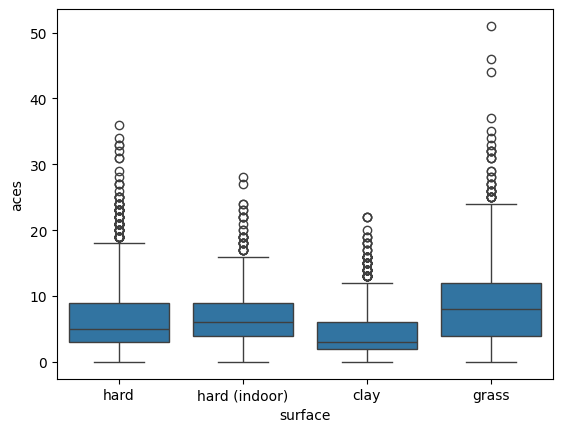

In [35]:
sns.boxplot(data=player_stats_df, y="aces", x="surface")

<Axes: xlabel='surface', ylabel='double_faults'>

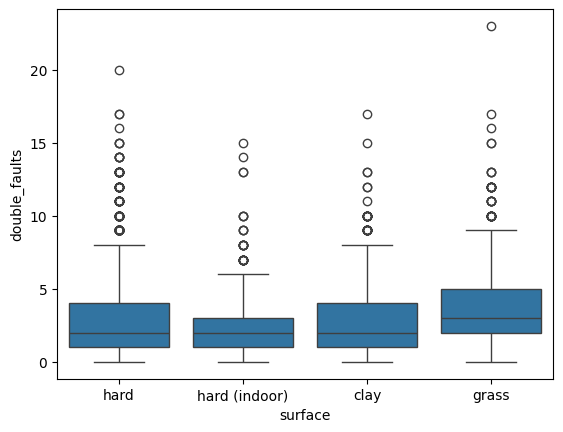

In [36]:
sns.boxplot(data=player_stats_df, y="double_faults", x="surface")

In [37]:
rankings_df = pd.read_csv("s3://matchedge-pipeline/data/clean/top_500_players.csv")

In [38]:
rankings_df = rankings_df.iloc[0:10,:]

In [39]:
rankings_df['rank'] = range(1, len(rankings_df) + 1)

In [40]:
player_stats_df = pd.merge(player_stats_df, rankings_df[["id", "rank"]], on="id", how="left").rename(columns={"rank": "live_ranking"})

In [43]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,return_games_played,net_points_won,winners,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,live_ranking
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,339,...,3.0,NaN,2.0,6.0,0.44,0.20,0.29,0.0,0.0,NaN
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,339,...,9.0,0.80,17.0,22.0,0.75,0.27,0.51,2.0,5.0,NaN
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,339,...,10.0,0.71,27.0,16.0,0.80,0.32,0.55,2.0,17.0,NaN
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,339,...,11.0,0.50,15.0,15.0,0.68,0.20,0.46,1.0,4.0,6.0
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,339,...,5.0,0.50,5.0,14.0,0.50,0.23,0.35,0.0,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,16.0,0.67,39.0,49.0,0.63,0.31,0.48,9.0,27.0,NaN
8194,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,15.0,0.17,27.0,45.0,0.65,0.42,0.52,10.0,6.0,NaN
8195,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,10.0,1.00,16.0,28.0,0.53,0.32,0.43,3.0,2.0,NaN
8196,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,10.0,0.67,26.0,25.0,0.66,0.33,0.52,3.0,9.0,NaN


<Axes: xlabel='live_ranking', ylabel='1st_serve_return_points_won'>

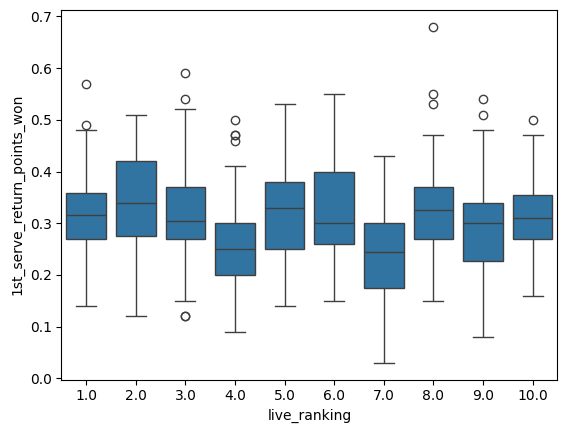

In [44]:
sns.boxplot(data=player_stats_df, y="1st_serve_return_points_won", x="live_ranking")

<Axes: xlabel='live_ranking', ylabel='2nd_serve_return_points_won'>

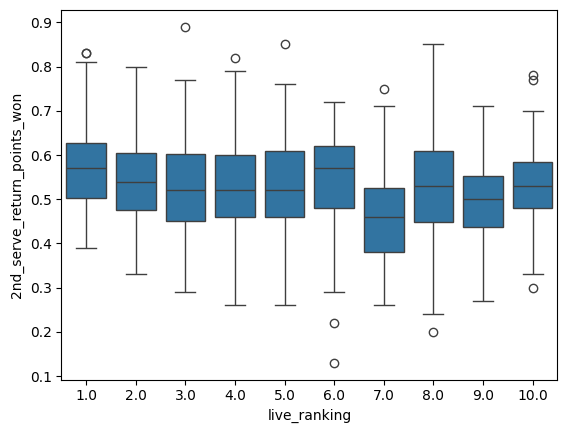

In [45]:
sns.boxplot(data=player_stats_df, y="2nd_serve_return_points_won", x="live_ranking")

In [46]:
avg_2nd_serve_return = player_stats_df.groupby(by=["live_ranking"])["2nd_serve_return_points_won"].mean().reset_index()

In [47]:
avg_2nd_serve_return

,live_ranking,2nd_serve_return_points_won
0,1.0,0.582581
1,2.0,0.545467
2,3.0,0.523625
3,4.0,0.534154
4,5.0,0.530656
5,6.0,0.539200
6,7.0,0.456061
7,8.0,0.526500
8,9.0,0.490667
9,10.0,0.537458


<Axes: xlabel='live_ranking', ylabel='2nd_serve_return_points_won'>

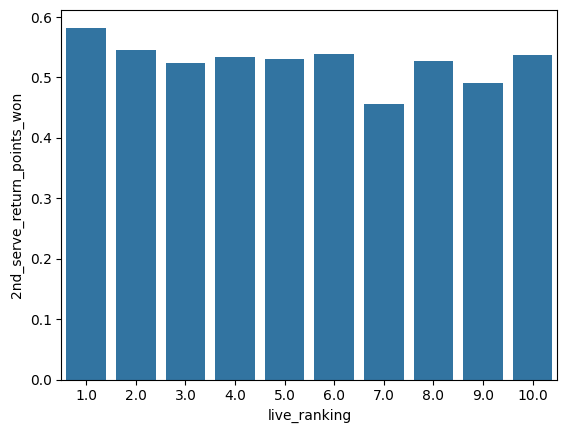

In [48]:
sns.barplot(data=avg_2nd_serve_return, y="2nd_serve_return_points_won", x="live_ranking")

In [49]:
avg_aces_top_10 = player_stats_df.groupby(by=["live_ranking"])["aces"].mean().reset_index()
avg_double_faults_top_10 = player_stats_df.groupby(by=["live_ranking"])["double_faults"].mean().reset_index()

<Axes: xlabel='live_ranking', ylabel='double_faults'>

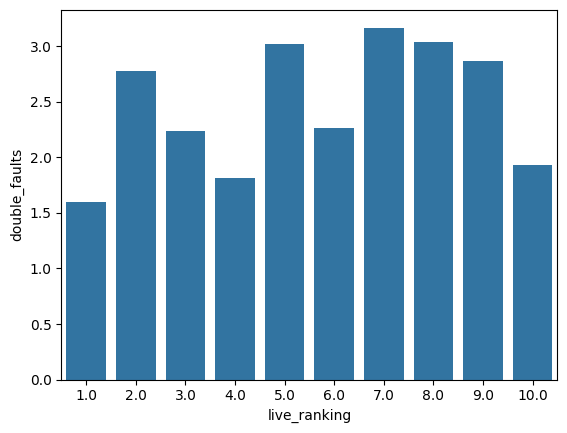

In [50]:
sns.barplot(data=avg_double_faults_top_10, y="double_faults", x="live_ranking")

<Axes: xlabel='live_ranking', ylabel='aces'>

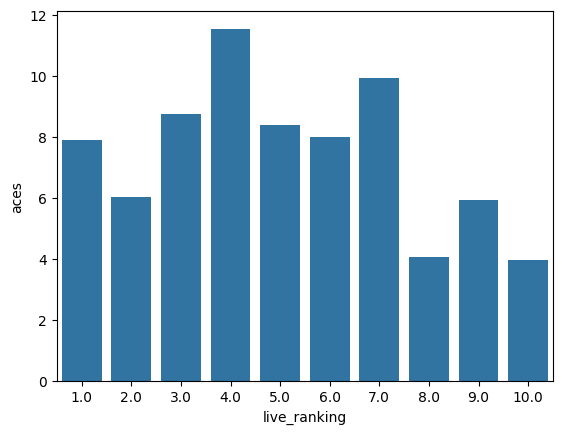

In [51]:
sns.barplot(data=avg_aces_top_10, y="aces", x="live_ranking")

In [52]:
rankings_df

,unnamed: 0,name,id,rank
0,0,J. Sinner,s0ag,1
1,1,C. Alcaraz,a0e2,2
2,2,A. Zverev,z355,3
3,3,T. Fritz,fb98,4
4,4,J. Draper,d0co,5
5,5,N. Djokovic,d643,6
6,6,B. Shelton,s0s1,7
7,7,A. de Minaur,dh58,8
8,8,H. Rune,r0dg,9
9,9,L. Musetti,m0ej,10


In [53]:
avg_aces = player_stats_df.groupby(by=["player"])["aces"].mean().reset_index().sort_values(by="aces", ascending=False).iloc[:10]
avg_double = player_stats_df.groupby(by=["player"])["double_faults"].mean().reset_index().sort_values(by="double_faults", ascending=False).iloc[:10]

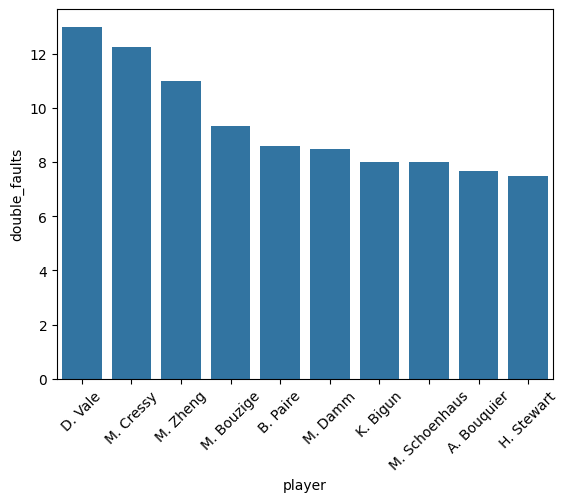

In [54]:
sns.barplot(data=avg_double, y="double_faults", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

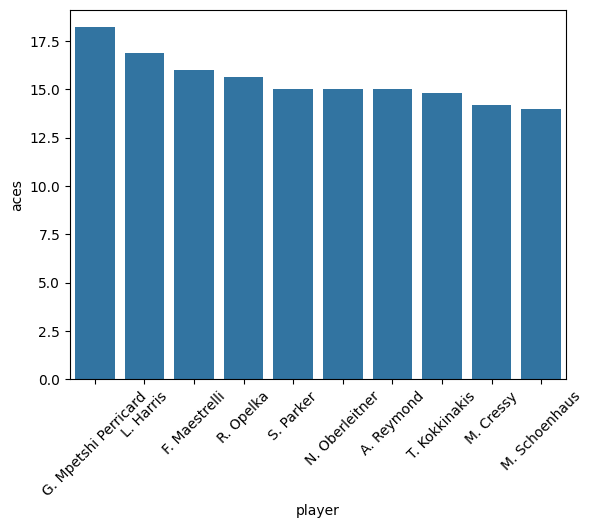

In [55]:
sns.barplot(data=avg_aces, y="aces", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

Lets make sure they have a big enough sample size

In [56]:
match_counts = player_stats_df["player"].value_counts().reset_index()
match_counts.columns = ["player", "match_count"]

avg_stats = player_stats_df.groupby(by="player")[["aces", "double_faults"]].mean().reset_index()

avg_stats = avg_stats.merge(match_counts, on="player")

filtered_data = avg_stats[avg_stats["match_count"] >= 20]

avg_aces = filtered_data.sort_values(by="aces", ascending=False).head(10)
avg_double = filtered_data.sort_values(by="double_faults", ascending=False).head(10)

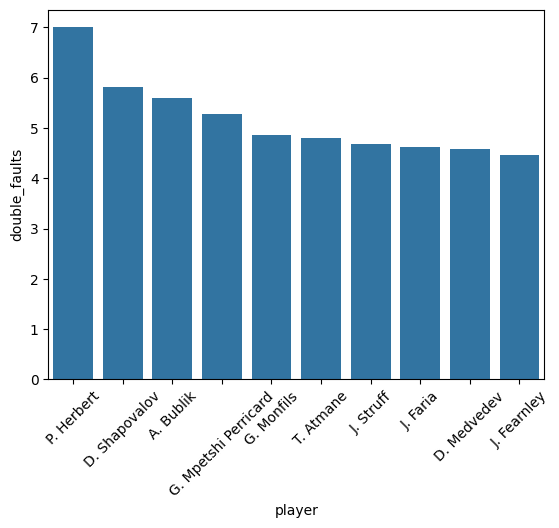

In [57]:
sns.barplot(data=avg_double, y="double_faults", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

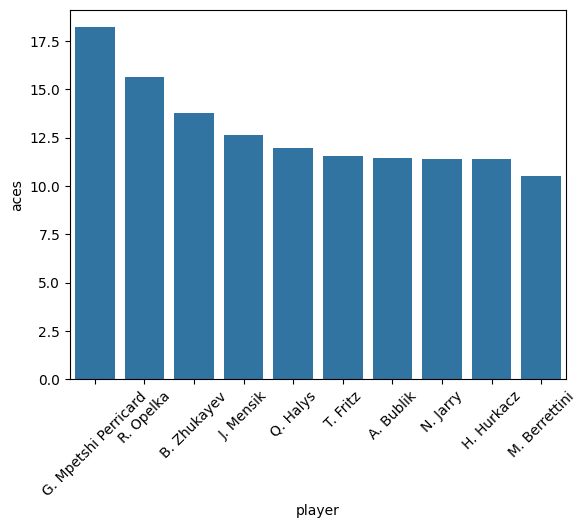

In [58]:
sns.barplot(data=avg_aces, y="aces", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

In [59]:
player_stats_df.columns

Index(['match_date', 'player', 'opponent', 'duration', 'match_round',
       'player_scores', 'opponent_scores', 'winner', 'result', 'tournament_id',
       'id', 'opponent_id', 'set1', 'set2', 'set3', 'set4', 'set5',
       'opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4',
       'opponent_set5', 'best_of', 'winner_id', 'year', 'level', 'location',
       'surface', 'serve_rating', 'aces', 'double_faults', 'first_serve',
       '1st_serve_points_won', '2nd_serve_points_won', 'break_points_saved',
       'service_games_played', 'return_rating', '1st_serve_return_points_won',
       '2nd_serve_return_points_won', 'break_points_converted',
       'return_games_played', 'net_points_won', 'winners', 'unforced_errors',
       'service_points_won', 'return_points_won', 'total_points_won',
       'break_point_opportunities', 'net_points_played', 'live_ranking'],
      dtype='object')

Create an outcome column as 0 if player lost 1 if player won

In [60]:
player_stats_df["target"] = (player_stats_df["id"] == player_stats_df["winner_id"]).astype(int)

Do straight sets win/lost column.

In [61]:
player_stats_df["best_of"].value_counts()

best_of
3    5964
5    2234
Name: count, dtype: int64

In [62]:
def straight_sets_win(row):
    if row["target"] == 0:
        return 0 
    if row["best_of"] == 3 and pd.isna(row["set3"]):
        return 1
    if row["best_of"] == 5 and pd.isna(row["set4"]):
        return 1
    return 0

player_stats_df["straight_sets_win"] = player_stats_df.apply(straight_sets_win, axis=1)


In [63]:
player_stats_df["straight_sets_win"]

0       0
1       1
2       1
3       0
4       0
       ..
8193    0
8194    0
8195    0
8196    1
8197    0
Name: straight_sets_win, Length: 8198, dtype: int64

In [65]:
def straight_sets_loss(row):
    if row["target"] == 1:
        return 0  # Player won, can't be a straight-sets loss
    if row["best_of"] == 3 and pd.isna(row["opponent_set3"]):
        return 1
    if row["best_of"] == 5 and pd.isna(row["opponent_set4"]):
        return 1
    return 0

player_stats_df["straight_sets_loss"] = player_stats_df.apply(straight_sets_loss, axis=1)


In [66]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,339,...,6.0,0.44,0.20,0.29,0.0,0.0,NaN,0,0,1
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,339,...,22.0,0.75,0.27,0.51,2.0,5.0,NaN,1,1,0
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,339,...,16.0,0.80,0.32,0.55,2.0,17.0,NaN,1,1,0
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,339,...,15.0,0.68,0.20,0.46,1.0,4.0,6.0,0,0,1
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,339,...,14.0,0.50,0.23,0.35,0.0,8.0,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,49.0,0.63,0.31,0.48,9.0,27.0,NaN,0,0,0
8194,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,45.0,0.65,0.42,0.52,10.0,6.0,NaN,0,0,0
8195,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,28.0,0.53,0.32,0.43,3.0,2.0,NaN,0,0,1
8196,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,25.0,0.66,0.33,0.52,3.0,9.0,NaN,1,1,0


#### Fix Some Issue With Retired Matches
When set 2 is missing this is definitely a RET

In [67]:
player_stats_df[['set1', 'set2', 'set3', 'set4', 'set5', 
                 'opponent_set1', 'opponent_set2', 'opponent_set3', 
                 'opponent_set4', 'opponent_set5']] = player_stats_df[['set1', 'set2', 'set3', 'set4', 'set5', 
                 'opponent_set1', 'opponent_set2', 'opponent_set3', 
                 'opponent_set4', 'opponent_set5']].astype('Int32')

In [68]:
mask = (player_stats_df["result"]=="Completed") & player_stats_df["set2"].isna()
player_stats_df.loc[mask, "result"] = "RET"

In best of 3 if second set didnt finish

In [69]:
mask = (player_stats_df["best_of"] == 3) & (player_stats_df["set2"] != 6) & (player_stats_df["set2"] != 7) &\
    (player_stats_df["opponent_set2"]!=6) & (player_stats_df["opponent_set2"]!=7) & (player_stats_df["result"] == "Completed")
player_stats_df.loc[mask, "result"] = "RET"

In best of 3 if third set didnt finish

In [70]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["straight_sets_loss"] == 0) & (player_stats_df["best_of"] == 3 ) &\
        (player_stats_df["set3"] != 6) & (player_stats_df["set3"] != 7) &\
            (player_stats_df["opponent_set3"]!=6) & (player_stats_df["opponent_set3"]!=7)

player_stats_df.loc[mask, "result"] = "RET"

In best of 5 if 3rd set is missing

In [71]:
mask = (player_stats_df["result"]=="Completed") & player_stats_df["set3"].isna() & (player_stats_df["best_of"] == 5) &\
    ~(player_stats_df["match_round"].str.contains('Qual'))
player_stats_df.loc[mask, "result"] = "RET"

Best of 5 win not win in straight but 3rd set not finished (and is not Next Gen ATP)

In [72]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["best_of"] == 5) & ~(player_stats_df["match_round"].str.contains('Qual')) &\
            (player_stats_df["set3"] != 6) & (player_stats_df["set3"] != 7) &\
            (player_stats_df["opponent_set3"]!=6) & (player_stats_df["opponent_set3"]!=7) &\
                (player_stats_df["tournament_id"] != 7696)
player_stats_df.loc[mask, "result"] = "RET"

In best of 5 sets and not in straight but set 4 not finished

In [73]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["best_of"] == 5) & ~(player_stats_df["match_round"].str.contains('Qual')) &\
            (player_stats_df["set4"] != 6) & (player_stats_df["set4"] != 7) &\
            (player_stats_df["opponent_set4"]!=6) & (player_stats_df["opponent_set4"]!=7) &\
                (player_stats_df["tournament_id"] != 7696)
player_stats_df.loc[mask, "result"] = "RET"

Where 5th set is not finished

In [74]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["best_of"] == 5) & ~(player_stats_df["match_round"].str.contains('Qual')) &\
            (player_stats_df["set5"] != 6) & (player_stats_df["set5"] != 7) &\
            (player_stats_df["opponent_set5"]!=6) & (player_stats_df["opponent_set5"]!=7) &\
                (player_stats_df["tournament_id"] != 7696)
player_stats_df.loc[mask, "result"] = "RET"

In [75]:
player_stats_df["result"].value_counts()

result
Completed    7990
RET           208
Name: count, dtype: int64

Change Qualifying round using str.contains('Qual) to best of 3

In [76]:
mask = (player_stats_df["best_of"] == 5) & (player_stats_df["match_round"].str.contains('Qual'))
player_stats_df.loc[mask, "best_of"] = 3

In [77]:
player_stats_df["best_of"].value_counts()

best_of
3    6970
5    1228
Name: count, dtype: int64

Create number of sets won/lost.

In [78]:
# List of player and opponent set columns in order
player_sets = ['set1', 'set2', 'set3', 'set4', 'set5']
opponent_sets = ['opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4', 'opponent_set5']

# Compute per-set win booleans for player
set_wins = pd.DataFrame({
    p: ((player_stats_df[p] == 6) & (player_stats_df[o] <= 4)) |  # normal win
       ((player_stats_df[p] == 7) & (player_stats_df[o] >= 5))    # tiebreak win
    for p, o in zip(player_sets, opponent_sets)
})

# Count wins per row for player
player_stats_df["sets_won"] = set_wins.sum(axis=1)

# Compute per-set win booleans for opponent
set_loses = pd.DataFrame({
    o: ((player_stats_df[o] == 6) & (player_stats_df[p] <= 4)) |  # normal win
       ((player_stats_df[o] == 7) & (player_stats_df[p] >= 5))    # tiebreak win
    for p, o in zip(player_sets, opponent_sets)
})

# Count wins for opponent per row
player_stats_df["sets_lost"] = set_loses.sum(axis=1)

In [79]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,return_points_won,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,sets_won,sets_lost
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,339,...,0.20,0.29,0.0,0.0,NaN,0,0,1,0,0
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,339,...,0.27,0.51,2.0,5.0,NaN,1,1,0,1,0
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,339,...,0.32,0.55,2.0,17.0,NaN,1,1,0,2,0
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,339,...,0.20,0.46,1.0,4.0,6.0,0,0,1,0,2
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,339,...,0.23,0.35,0.0,8.0,NaN,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,0.31,0.48,9.0,27.0,NaN,0,0,0,1,2
8194,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,0.42,0.52,10.0,6.0,NaN,0,0,0,1,2
8195,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,0.32,0.43,3.0,2.0,NaN,0,0,1,0,2
8196,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,0.33,0.52,3.0,9.0,NaN,1,1,0,2,0


---

Winner id thats neither player_id or opponent_id

In [81]:
mask = (player_stats_df["winner_id"] != player_stats_df["id"]) & \
       (player_stats_df["winner_id"] != player_stats_df["opponent_id"])

mismatches = player_stats_df[mask]

player_stats_df["winner_not_in_match"] = (
    (player_stats_df["winner_id"] != player_stats_df["id"]) &
    (player_stats_df["winner_id"] != player_stats_df["opponent_id"])
)
mismatch_count = (
    ((player_stats_df["winner_id"] != player_stats_df["id"]) &
     (player_stats_df["winner_id"] != player_stats_df["opponent_id"]))
    .sum()
)

print(mismatch_count)


0


In [82]:
player_stats_df[player_stats_df["winner_not_in_match"]==True]

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,sets_won,sets_lost,winner_not_in_match


Perfect!

In [83]:
mismatch_count = (
    ((player_stats_df["winner_id"] != player_stats_df["id"]) &
     (player_stats_df["winner_id"] != player_stats_df["opponent_id"]))
    .sum()
)

mismatch_pct = mismatch_count / len(player_stats_df) * 100


In [84]:
print(mismatch_pct)

0.0


0% are wrong. Thats great.

In [85]:
player_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8198 entries, 0 to 8197
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   match_date                   8198 non-null   object 
 1   player                       8198 non-null   object 
 2   opponent                     8198 non-null   object 
 3   duration                     6900 non-null   object 
 4   match_round                  8198 non-null   object 
 5   player_scores                8198 non-null   object 
 6   opponent_scores              8198 non-null   object 
 7   winner                       8198 non-null   object 
 8   result                       8198 non-null   object 
 9   tournament_id                8198 non-null   int64  
 10  id                           8198 non-null   object 
 11  opponent_id                  8198 non-null   object 
 12  set1                         8198 non-null   Int32  
 13  set2              

Delete some redundant columns

In [86]:
player_stats_df.drop(columns=["player_scores", "opponent_scores"], inplace=True)

#### Save DataFrame

#### Rename Columns Appropriately

In [87]:
player_stats_df.rename(columns={'first_serve': 'first_serve_percentage', 
                                '1st_serve_points_won': '1st_serve_percentage_won', 
                                '2nd_serve_points_won': '2nd_serve_percentage_won', 
                                'break_points_saved': 'break_points_percentage_saved', 
                                '1st_serve_return_points_won': '1st_serve_return_percentage_won',
                                '2nd_serve_return_points_won': '2nd_serve_return_percentage_won', 
                                'break_points_converted': 'break_points_converted_percentage', 
                                'net_points_won': 'percent_net_points_won',
                                'service_points_won': 'service_points_percent_won', 
                                'return_points_won': 'return_points_percent_won',
                                'total_points_won': 'percent_total_points_won', 
                                }, inplace=True)

In [88]:
player_stats_df.columns

Index(['match_date', 'player', 'opponent', 'duration', 'match_round', 'winner',
       'result', 'tournament_id', 'id', 'opponent_id', 'set1', 'set2', 'set3',
       'set4', 'set5', 'opponent_set1', 'opponent_set2', 'opponent_set3',
       'opponent_set4', 'opponent_set5', 'best_of', 'winner_id', 'year',
       'level', 'location', 'surface', 'serve_rating', 'aces', 'double_faults',
       'first_serve_percentage', '1st_serve_percentage_won',
       '2nd_serve_percentage_won', 'break_points_percentage_saved',
       'service_games_played', 'return_rating',
       '1st_serve_return_percentage_won', '2nd_serve_return_percentage_won',
       'break_points_converted_percentage', 'return_games_played',
       'percent_net_points_won', 'winners', 'unforced_errors',
       'service_points_percent_won', 'return_points_percent_won',
       'percent_total_points_won', 'break_point_opportunities',
       'net_points_played', 'live_ranking', 'target', 'straight_sets_win',
       'straight_sets_los

In [89]:
player_stats_df.to_csv("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/ML-Dashboard/player_stats.csv", sep=",", columns=player_stats_df.columns, index=False)

In [51]:
player_stats_df = pd.read_csv("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/ML-Dashboard/player_stats.csv")

In [90]:
player_stats_df['match_date'] = pd.to_datetime(player_stats_df['match_date'].astype(str).str.split().str[0], errors='coerce')

In [91]:
player_stats_df

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,percent_total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,sets_won,sets_lost,winner_not_in_match
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,J. Lehecka,RET,339,o522,l0bv,...,0.29,0.0,0.0,NaN,0,0,1,0,0,False
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,J. Lehecka,RET,339,l0bv,d875,...,0.51,2.0,5.0,NaN,1,1,0,1,0,False
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,R. Opelka,Completed,339,o522,m0gz,...,0.55,2.0,17.0,NaN,1,1,0,2,0,False
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,R. Opelka,Completed,339,d643,o522,...,0.46,1.0,4.0,6.0,0,0,1,0,2,False
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,G. Dimitrov,RET,339,tc61,d875,...,0.35,0.0,8.0,NaN,0,0,1,0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,T. Monteiro,Completed,319,o0ad,mj08,...,0.48,9.0,27.0,NaN,0,0,0,1,2,False
8194,2025-07-19,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,R. Albot,Completed,319,k0ep,a829,...,0.52,10.0,6.0,NaN,0,0,0,1,2,False
8195,2025-07-19,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,F. Bagnis,Completed,319,r0go,bf23,...,0.43,3.0,2.0,NaN,0,0,1,0,2,False
8196,2025-07-19,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,J. Rodionov,Completed,319,r09x,k0cj,...,0.52,3.0,9.0,NaN,1,1,0,2,0,False


## Feature Engineering

In [92]:
def generate_rolling_features(df, stats_cols=None, N_list=[3, 5, 10]):
    """
    Generates rolling and lagged features for tennis matches using in-play stats.
    Avoids DataFrame fragmentation by concatenating results in batches.
    """

    df = df.copy()
    df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')  # keep datetime
    df = df.sort_values(['player', 'match_date'])

    if stats_cols is None:
        stats_cols = [
            'serve_rating', 'aces', 'double_faults', 'first_serve_percentage',
            '1st_serve_percentage_won', '2nd_serve_percentage_won',
            'break_points_percentage_saved', 'service_games_played', 'return_rating',
            '1st_serve_return_percentage_won', '2nd_serve_return_percentage_won',
            'break_points_converted_percentage', 'return_games_played',
            'percent_net_points_won', 'winners', 'unforced_errors',
            'service_points_percent_won', 'return_points_percent_won',
            'percent_total_points_won', 'break_point_opportunities', 'net_points_played'
        ]

    all_new_cols = []

    # Player-based rolling features
    for N in N_list:
        rolling_group = df.groupby('player', group_keys=False)[stats_cols]
        rolled_mean = rolling_group.apply(lambda x: x.shift().rolling(N, min_periods=1).mean())
        rolled_sum = rolling_group.apply(lambda x: x.shift().rolling(N, min_periods=1).sum())

        rolled_mean.columns = [f'{col}_rolling_mean_{N}' for col in stats_cols]
        rolled_sum.columns = [f'{col}_rolling_sum_{N}' for col in stats_cols]

        all_new_cols.append(rolled_mean)
        all_new_cols.append(rolled_sum)

    # Surface-specific rolling
    for N in N_list:
        surface_group = df.groupby(['player', 'surface'], group_keys=False)[stats_cols]
        surf_mean = surface_group.apply(lambda x: x.shift().rolling(N, min_periods=1).mean())
        surf_mean.columns = [f'{col}_surf_mean_{N}' for col in stats_cols]
        all_new_cols.append(surf_mean)

    # Head-to-head rolling stats
    for N in N_list:
        h2h_group = df.groupby(['player', 'opponent'], group_keys=False)

        h2h_wins = h2h_group['target'].apply(
            lambda x: x.shift().rolling(N, min_periods=1).apply(lambda s: np.sum(s == 1), raw=False)
        )
        h2h_wins.name = f'h2h_wins_{N}'
        all_new_cols.append(h2h_wins)

        h2h_sets_diff = h2h_group['sets_won'].transform(
    lambda x: (x - h2h_group['sets_lost'].get_group(x.name)).shift().rolling(N, min_periods=1).sum()
)

        h2h_sets_diff.name = f'h2h_sets_diff_{N}'
        all_new_cols.append(h2h_sets_diff)

    # Recent win rate
    for N in N_list:
        win_rate = df.groupby('player')['target'].apply(
            lambda x: x.shift().rolling(N, min_periods=1).mean()
        )
        win_rate.name = f'recent_win_rate_{N}'
        all_new_cols.append(win_rate)

    # Ranking difference & trend
            # ranking_diff = df['live_ranking'] - df['opponent'].map(
            #     df.groupby('player')['live_ranking'].last()
            # )
            # ranking_diff.name = 'ranking_diff'
            # all_new_cols.append(ranking_diff)

            # for N in N_list:
            #     rank_change = df.groupby('player')['live_ranking'].apply(
            #         lambda x: x.shift(N) - x
            #     )
            #     rank_change.name = f'ranking_change_{N}'
            #     all_new_cols.append(rank_change)

    # Merge all at once
    df = pd.concat([df] + all_new_cols, axis=1)

    return df

In [93]:
def format_stat_cols(df, tournament_order):
    """
    Formats key columns in the match statistics DataFrame by setting appropriate data types.

    Parameters:
        df (pd.DataFrame): The input DataFrame with raw statistical data.
        tournament_order (list): Ordered list of tournament levels for categorical conversion.

    Returns:
        pd.DataFrame: The DataFrame with properly typed and formatted columns.
    """
    # Convert identifiers and player/opponent info
    df['player'] = df['player'].astype('string')
    df['opponent'] = df['opponent'].astype('string')
    df['id'] = df['id'].astype('string').str.lower()
    df['opponent_id'] = df['opponent_id'].astype('string').str.lower()
    df['tournament_id'] = df['tournament_id'].astype('Int64')
    df['winner'] = df['winner'].astype('string')

    # Tournament info
    df['level'] = pd.Categorical(df['level'], categories=tournament_order, ordered=True)
    df['location'] = df['location'].astype('string')
    df['surface'] = df['surface'].astype('category')

    # Dates and duration
    df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce').dt.date

    df['year'] = df['year'].astype('Int64')
    df['duration'] = pd.to_timedelta(df['duration'], errors='coerce')

    # Integer columns
    int_cols = [
        'set1', 'set2', 'set3', 'set4', 'set5',
        'opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4', 'opponent_set5',
        'best_of', 'target', 'straight_sets_win', 'straight_sets_loss',
        'sets_won', 'sets_lost', 'live_ranking'
    ]
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    # Float/stat columns
    stats_cols = [
        'serve_rating', 'aces', 'double_faults', 'first_serve_percentage',
        '1st_serve_percentage_won', '2nd_serve_percentage_won',
        'break_points_percentage_saved', 'service_games_played', 'return_rating',
        '1st_serve_return_percentage_won', '2nd_serve_return_percentage_won',
        'break_points_converted_percentage', 'return_games_played',
        'percent_net_points_won', 'winners', 'unforced_errors',
        'service_points_percent_won', 'return_points_percent_won',
        'percent_total_points_won', 'break_point_opportunities', 'net_points_played'
    ]
    for col in stats_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


In [94]:
tournament_order = [
    'Next Gen ATP Finals',
    'ATP 250',
    'ATP 500',
    'ATP 1000',
    'Nitto ATP Finals',
    'Grand Slam'
]
rolling_stats_df = format_stat_cols(player_stats_df, tournament_order=tournament_order)

In [96]:
player_stats_atp_df = player_stats_df[player_stats_df["best_of"] != 5].copy()

In [97]:
player_stats_atp_df = player_stats_atp_df[player_stats_atp_df['duration'].notna()]

In [98]:
player_stats_atp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6404 entries, 0 to 8197
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype          
---  ------                             --------------  -----          
 0   match_date                         6404 non-null   object         
 1   player                             6404 non-null   string         
 2   opponent                           6404 non-null   string         
 3   duration                           6404 non-null   timedelta64[ns]
 4   match_round                        6404 non-null   object         
 5   winner                             6404 non-null   string         
 6   result                             6404 non-null   object         
 7   tournament_id                      6404 non-null   Int64          
 8   id                                 6404 non-null   string         
 9   opponent_id                        6404 non-null   string         
 10  set1                         

In [102]:
player_stats_atp_df = player_stats_atp_df[player_stats_atp_df['result'] != 'RET']

In [103]:
player_stats_atp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6248 entries, 2 to 8197
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype          
---  ------                             --------------  -----          
 0   match_date                         6248 non-null   object         
 1   player                             6248 non-null   string         
 2   opponent                           6248 non-null   string         
 3   duration                           6248 non-null   timedelta64[ns]
 4   match_round                        6248 non-null   object         
 5   winner                             6248 non-null   string         
 6   result                             6248 non-null   object         
 7   tournament_id                      6248 non-null   Int64          
 8   id                                 6248 non-null   string         
 9   opponent_id                        6248 non-null   string         
 10  set1                         

In [ ]:
player_stats_atp_df.drop(columns='live_ranking', inplace=True)

In [106]:
player_stats_atp_df.drop(columns='winner_not_in_match', inplace=True)

In [114]:
player_stats_atp_df = format_stat_cols(player_stats_df, tournament_order=tournament_order)

In [115]:
player_stats_atp_df

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,percent_total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,sets_won,sets_lost,winner_not_in_match
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,J. Lehecka,RET,339,o522,l0bv,...,0.29,0.0,0.0,<NA>,0,0,1,0,0,False
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,J. Lehecka,RET,339,l0bv,d875,...,0.51,2.0,5.0,<NA>,1,1,0,1,0,False
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,R. Opelka,Completed,339,o522,m0gz,...,0.55,2.0,17.0,<NA>,1,1,0,2,0,False
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,R. Opelka,Completed,339,d643,o522,...,0.46,1.0,4.0,6,0,0,1,0,2,False
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,G. Dimitrov,RET,339,tc61,d875,...,0.35,0.0,8.0,<NA>,0,0,1,0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,T. Monteiro,Completed,319,o0ad,mj08,...,0.48,9.0,27.0,<NA>,0,0,0,1,2,False
8194,2025-07-19,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,R. Albot,Completed,319,k0ep,a829,...,0.52,10.0,6.0,<NA>,0,0,0,1,2,False
8195,2025-07-19,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,F. Bagnis,Completed,319,r0go,bf23,...,0.43,3.0,2.0,<NA>,0,0,1,0,2,False
8196,2025-07-19,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,J. Rodionov,Completed,319,r09x,k0cj,...,0.52,3.0,9.0,<NA>,1,1,0,2,0,False


In [116]:
player_stats_atp_df = generate_rolling_features(player_stats_df)

/var/folders/b3/8dnps2js0rz1xgw1gkx248p40000gn/T/ipykernel_58215/1542774931.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surface_group = df.groupby(['player', 'surface'], group_keys=False)[stats_cols]
/var/folders/b3/8dnps2js0rz1xgw1gkx248p40000gn/T/ipykernel_58215/1542774931.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surface_group = df.groupby(['player', 'surface'], group_keys=False)[stats_cols]
/var/folders/b3/8dnps2js0rz1xgw1gkx248p40000gn/T/ipykernel_58215/1542774931.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda

In [117]:
player_stats_atp_df

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,net_points_played_surf_mean_10,h2h_wins_3,h2h_sets_diff_3,h2h_wins_5,h2h_sets_diff_5,h2h_wins_10,h2h_sets_diff_10,recent_win_rate_3,recent_win_rate_5,recent_win_rate_10
5190,2025-03-29,A. Andrade,P. Maloney,0 days 01:43:58,1st Round Qualifying,P. Maloney,RET,717,ag08,m0re,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6335,2024-07-14,A. Andreev,R. Molleker,0 days 01:08:00,1st Round Qualifying,R. Molleker,Completed,540,a0ab,m0ac,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7430,2024-10-20,A. Andreev,L. Djere,0 days 01:32:00,1st Round Qualifying,L. Djere,Completed,429,a0ab,db63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,2024-12-28,A. Andreev,C. Tseng,0 days 02:52:37,1st Round Qualifying,A. Andreev,Completed,339,a0ab,t0ap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4131,2024-12-29,A. Andreev,B. Bonzi,0 days 00:20:21,2nd Round Qualifying,B. Bonzi,RET,339,a0ab,bm95,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(Z. Zhang, 509)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.2,0.2
"(Z. Zhang, 4605)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,0.4,0.2
"(Z. Zhang, 634)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,0.4,0.2
"(Z. Zhang, 4818)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.4,0.2
